<a href="https://colab.research.google.com/github/Elizabeth5335/python-User_behavior_analysis/blob/main/User_behavior_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Project Description**

The main goal of this project is to analyze user behavior across different segments, including traffic channels, device types, subscription status, and geography.

The analysis covers user engagement metrics (sessions, accounts, verifications), sales dynamics, and statistical testing to identify significant differences between groups.

Link to Tableau:
[Customer Behavior Dashboard](https://public.tableau.com/views/CustomerBehavior_17720571039910/CustomersDashboard?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)



##**Data Preparation**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, normaltest, mannwhitneyu, kruskal, chi2_contingency
import statsmodels.api as sm
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.ticker as mtick

In [ ]:
# !pip install --upgrade google-cloud-bigquery

from google.colab import auth
from google.cloud import bigquery
auth.authenticate_user()
client = bigquery.Client(project="data-analytics-mate")

query = """
SELECT
    s.date,
    s.ga_session_id AS session_id,
    sp.continent,
    sp.country,
    sp.device,
    sp.browser,
    sp.mobile_model_name,
    sp.operating_system,
    sp.`language` AS browser_language,
    sp.medium AS traffic_source,
    sp.channel AS traffic_channel,
    p.category AS product_category,
    p.name AS product_name,
    p.price AS product_price,
    p.short_description AS product_description,
    acs.account_id,
    a.is_verified,
    a.is_unsubscribed

FROM `data-analytics-mate.DA.session` AS s
INNER JOIN `data-analytics-mate.DA.session_params` AS sp
    ON s.ga_session_id = sp.ga_session_id
LEFT JOIN `data-analytics-mate.DA.order` AS o
    ON s.ga_session_id = o.ga_session_id
LEFT JOIN `data-analytics-mate.DA.product` AS p
    ON o.item_id = p.item_id
LEFT JOIN `data-analytics-mate.DA.account_session` AS acs
    ON s.ga_session_id = acs.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account` AS a
    ON acs.account_id = a.id
"""

query_job = client.query(query)
results = query_job.result()

df = results.to_dataframe()


##**1. Data Overview**

####**Dataset Overview**
The dataset consists of 349545 rows and 18 columns, covering global sales activity from November 2020 to January 2021 (included).

There are 6 continents and 108 countries.

There are 550 products within 14 catefories with average price of \$953.30 and median price of \$445.00. The difference between mean and median demonstrates the presence of outliers.


**Columns:**

*General:*
* 'date'
* 'session_id'

*Geography:*

* 'continent'
* 'country'

*Technical details:*

* 'device'
* 'browser'
* 'mobile_model_name'
* 'operating_system'
* 'browser_language'
* 'traffic_source'
* 'traffic_channel'

*Order details:*
* 'product_category'
* 'product_name'
* 'product_price'
* 'product_description'

*Account details:*
* 'account_id'
* 'is_verified'
* 'is_unsubscribed'


Numeric columns: product_price (float); session_id and account_id (integers, but should not be analyzed as numeric variables); is_verified and is_unsubscribed (technically integers, but binary variables with values 0 (False) and 1 (True)).

There is one column (date) with the `dbdate` data type, which has been cast to the standard `datetime` type.

###**Data issues**

**1. Missing values**

Due to the LEFT JOIN in SQL, there are many rows with empty values (for example, when a user with a given `session_id` does not have an account and has not made any orders). However, only the `browser_language` column contains truly missing values. These have been replaced with `undefined`.

**2. Data quality**

*Note: as this is a test dataset, issues with `operating_system` and `traffic_channel` are considered "not a bug but a feature" and are treated as correct. Issues with `mobile_model_name` and `traffic_source` (medium) make the data unreliable, so these columns will be excluded from the analysis.*

1. The `operating_system` field contains the value *Web* which is not an operating system. However, almost 60% of sessions have this value. This affects the quality of analysis, and the root cause of this issue should be investigated.

2. The `mobile_model_name` field is expected to contain mobile device names. However, is contains invalid values (browser names and Chromebook) in at least 51% of rows, as well as values corresponding to desktop devices (usually incorrectly). Therefore, this column should not be used in the analysis, as it does not contain reliable data.

3. There is a major misalignment between `traffic_channel` and `traffic_source`. High-level channels do not match their underlying technical sources.

    The `traffic_channel` column provides a cleaner, aggregated view, but the underlying `traffic_source` is currently not trustworthy due to severe data noise and tagging errors.

**3. Duplicates**

No duplicates were found.

**4. Anomalies**

The `product_price` field contains strong outliers, most likely driven by premium-priced items. Therefore, using medians rather than averages when comparing prices is recommended.

####**General overview**

In [ ]:
df.head()

,date,session_id,continent,country,device,browser,mobile_model_name,operating_system,browser_language,traffic_source,traffic_channel,product_category,product_name,product_price,product_description,account_id,is_verified,is_unsubscribed
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm",<NA>,<NA>,<NA>
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,organic,Organic Search,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm",<NA>,<NA>,<NA>
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(none),Direct,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm",<NA>,<NA>,<NA>
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(none),Direct,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm",<NA>,<NA>,<NA>
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(none),Direct,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm",<NA>,<NA>,<NA>


In [ ]:
print(f"Columns:\n{df.columns}\n")
df.info()

Columns:
Index(['date', 'session_id', 'continent', 'country', 'device', 'browser',
       'mobile_model_name', 'operating_system', 'browser_language',
       'traffic_source', 'traffic_channel', 'product_category', 'product_name',
       'product_price', 'product_description', 'account_id', 'is_verified',
       'is_unsubscribed'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   date                 349545 non-null  dbdate 
 1   session_id           349545 non-null  Int64  
 2   continent            349545 non-null  object 
 3   country              349545 non-null  object 
 4   device               349545 non-null  object 
 5   browser              349545 non-null  object 
 6   mobile_model_name    349545 non-null  object 
 7   operating_system     349545 non-null  object 
 8   browser_language 

In [ ]:
# casting date field to datetime
df['date'] = pd.to_datetime(df['date'])
print(df['date'].dtype)

datetime64[ns]


**Missing values**

In [ ]:
missing_data = df.isnull().sum()

print("Columns with missing values:")
print(missing_data[missing_data > 0])

Columns with missing values:
browser_language       114266
product_category       316007
product_name           316007
product_price          316007
product_description    316007
account_id             321600
is_verified            321600
is_unsubscribed        321600
dtype: int64


**Duplicates**

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
print(f"Total sessions: {df.shape[0]}")
print(f"Unique sessions: {df['session_id'].nunique()}")

print(f"Total accounts: {df.shape[0] - df['account_id'].isna().sum()}")
print(f"Unique accounts: {df['account_id'].nunique()}")

Total sessions: 349545
Unique sessions: 349545
Total accounts: 27945
Unique accounts: 27945


No duplicates detected

####**Session Parameters**

In [ ]:
print(f"Dataset contains data from {df['date'].min()} to {df['date'].max()}\n") #exactly 3 months
print(f"There are {df['continent'].nunique()} continents and {df['country'].nunique()} countries")

Dataset contains data from 2020-11-01 00:00:00 to 2021-01-31 00:00:00

There are 6 continents and 108 countries


In [ ]:
print(f"Devices: {df['device'].unique()}")
print(f"Browsers: {df['browser'].unique()}")

Devices: ['desktop' 'mobile' 'tablet']
Browsers: ['Chrome' 'Safari' 'Android Webview' '<Other>' 'Edge' 'Firefox']


In [ ]:
print(f"Operating Systems: {df['operating_system'].unique()}\n") # Note! Contains 'Web' which is not OS
print(f"Distribution of users in operating system (%):\n{df['operating_system'].value_counts() / df['operating_system'].shape[0] * 100}")

Operating Systems: ['Macintosh' 'Web' 'Android' 'Windows' 'iOS' '<Other>']

Distribution of users in operating system (%):
operating_system
Web          58.335551
Windows      11.711511
iOS          11.472629
Android       8.527657
Macintosh     7.471427
<Other>       2.481226
Name: count, dtype: float64


In [ ]:
print(f"mobile_model_name: {df['mobile_model_name'].unique()}\n") # Note! Contains browsers instead of mobile models
print(f"Distribution of users in mobile_model_name:\n{df['mobile_model_name'].value_counts() / df['mobile_model_name'].notna().sum() * 100}")

incorrect = df['mobile_model_name'].isin(['Chrome', 'Safari', 'Firefox', 'Edge', 'Opera'])

pct = incorrect.sum() / df['mobile_model_name'].notna().sum() * 100

print(f"% of incorrect mobile_model_name values: {pct:.2f}%")

mobile_model_name: ['Safari' 'Chrome' '<Other>' 'iPhone' 'Pixel 3' 'ChromeBook' 'iPad'
 'Pixel 4 XL' 'Edge' 'Firefox']

Distribution of users in mobile_model_name:
mobile_model_name
Chrome        27.823027
iPhone        20.405384
Safari        20.280937
<Other>       20.266060
ChromeBook     5.459669
Edge           2.262084
iPad           1.456179
Firefox        1.394384
Pixel 4 XL     0.356463
Pixel 3        0.295813
Name: count, dtype: float64
% of incorrect mobile_model_name values: 51.76%


In [ ]:
print(f"Browser languages: {df['browser_language'].unique()}")
print(f"Missing values: {df['browser_language'].isna().sum()}")
print(f"% of missing values: {df['browser_language'].isna().sum() / df['browser_language'].shape[0] * 100:.2f}%")
df['browser_language'] = df['browser_language'].fillna('undefined')
print(df['browser_language'].value_counts())

Browser languages: ['zh' 'en-us' 'es-es' None 'en-gb' 'en-ca' 'fr' 'ko' 'en' 'de']
Missing values: 114266
% of missing values: 32.69%
browser_language
en-us        159893
undefined    114266
en-gb         24774
zh            12222
en            11518
en-ca          9332
es-es          5760
fr             5652
de             3387
ko             2741
Name: count, dtype: int64


There are 9 languages. The `browser_language` field has 114266 missing values (32.69%). Missing values were replaced with 'undefined'

In [ ]:
print(df['traffic_channel'].unique())
print(df['traffic_source'].unique())

['Paid Search' 'Organic Search' 'Direct' 'Undefined' 'Social Search']
['<Other>' 'organic' '(none)' '(data deleted)' 'referral' 'cpc']


In [ ]:
pd.crosstab(df['traffic_channel'], df['traffic_source'], normalize='index')

traffic_source,(data deleted),(none),<Other>,cpc,organic,referral
traffic_channel,,,,,,
Direct,0.000000,1.0,0.000000,0.000000,0.000000,0.000000
Organic Search,0.000000,0.0,0.000008,0.122556,0.877436,0.000000
Paid Search,0.004017,0.0,0.536267,0.000011,0.104398,0.355307
Social Search,0.000000,0.0,0.000000,0.000000,0.000000,1.000000
Undefined,0.999860,0.0,0.000000,0.000000,0.000000,0.000140


There is a major misalignment between `traffic_channel` and `traffic_source` (medium). High-level channels do not match their underlying technical sources.
    
Only a tiny fraction (< 0.01%) of Paid Search is correctly tagged as cpc. Instead, 53% is lost in `<Other>` and 35% is misclassified as referral, indicating broken UTM tracking or auto-tagging issues.


####**Accounts**

In [ ]:
print(f"There are {df['account_id'].nunique()} accounts, {df['is_verified'].sum()} of which have verified their emails")
print(f"{df['is_unsubscribed'].sum()} users have unsubscribed from newsletter")

There are 27945 accounts, 20036 of which have verified their emails
4735 users have unsubscribed from newsletter


####**Products**

In [ ]:
print(f"There are {df['product_name'].nunique()} products within {df['product_category'].nunique()} catefories")

There are 550 products within 14 catefories


In [ ]:
df['product_price'].describe().round(2)

,product_price
count,33538.0
mean,953.3
std,1317.0
min,3.0
25%,170.0
50%,445.0
75%,1195.0
max,9585.0


In [ ]:
print(f"Average price: {df['product_price'].mean():.2f}, median price: {df['product_price'].median():.2f}")

Average price: 953.30, median price: 445.00


The mean is significantly higher than the median, indicating the presence of strong outliers, most likely driven by premium-priced items.

In [ ]:
Q1 = df['product_price'].quantile(0.25)
Q3 = df['product_price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_df = df[(df['product_price'] < lower_bound) | (df['product_price'] > upper_bound)]

print("IQR Method:")
print(f"Bounds: {lower_bound} to {upper_bound}")
print(f"Number of outliers: {len(outliers_df)} ({(len(outliers_df) / df['product_price'].count()) * 100:.2f}%)")


IQR Method:
Bounds: -1367.5 to 2732.5
Number of outliers: 2826 (8.43%)


##**2. Exploratory & Statistical Analysis**

In [ ]:
df.columns

Index(['date', 'session_id', 'continent', 'country', 'device', 'browser',
       'mobile_model_name', 'operating_system', 'browser_language',
       'traffic_source', 'traffic_channel', 'product_category', 'product_name',
       'product_price', 'product_description', 'account_id', 'is_verified',
       'is_unsubscribed'],
      dtype='object')

In [ ]:
#Key Metrics

# Sessions
total_sessions = df['session_id'].nunique()
print(f"Total sessions: {total_sessions}")

# Registrations
total_accounts = df['account_id'].nunique()
df['has_account'] = df['account_id'].notna().astype(int)
registration_rate = total_accounts / total_sessions * 100
print(f"Total accounts: {total_accounts} ({registration_rate:.2f}% of sessions)")

# Email Verification
total_verified = df[df['is_verified'] == 1]['account_id'].nunique()
verified_pct = total_verified / total_accounts * 100
print(f"Total verified: {total_verified} ({verified_pct:.2f}% of accounts)")

# Unsubscribe
total_unsubscribed = df[df['is_unsubscribed'] == 1]['account_id'].nunique()
unsubscription_rate = total_unsubscribed / total_accounts * 100
print(f"Total unsubscribed: {total_unsubscribed} ({unsubscription_rate:.2f}% of accounts)")

# Account Health
is_active_account = df[(df['is_unsubscribed'] == 0) & (df['is_verified'] == 1)]
df['is_active_account'] = is_active_account['account_id'].notna()
df['is_active_account'] = df['is_active_account'].fillna(0).astype(int)

vs_rate = (is_active_account['is_verified'].sum() / total_accounts) * 100
print(f"Active Verified Subscriptions: {is_active_account['is_verified'].sum()} ({vs_rate:.2f}% of accounts)")

# Purchases
df['has_purchased'] = df['product_price'].notna().astype(int)
total_purchases = df['has_purchased'].sum()
purchase_rate = total_purchases / total_sessions * 100
print(f"\nTotal purchases: {total_purchases} ({purchase_rate:.2f}% of all sessions)")

Total sessions: 349545
Total accounts: 27945 (7.99% of sessions)
Total verified: 20036 (71.70% of accounts)
Total unsubscribed: 4735 (16.94% of accounts)
Active Verified Subscriptions: 15732 (56.30% of accounts)

Total purchases: 33538 (9.59% of all sessions)


In [ ]:
color_palette = ['#808080','#6BAED6'] #grey and blue

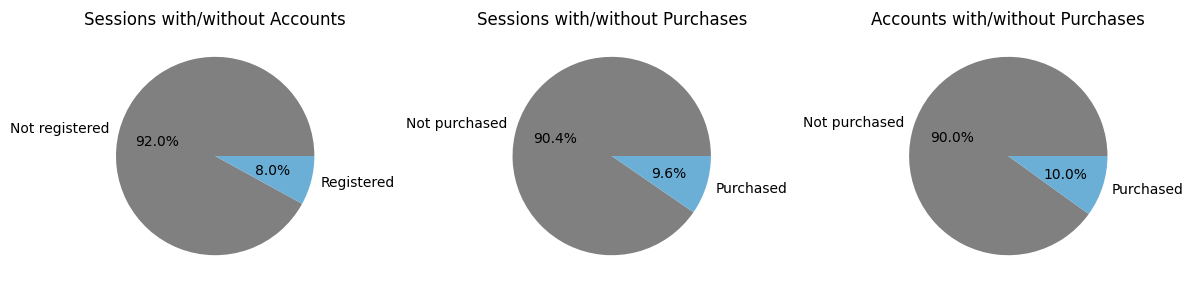

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(12, 8))

ax[0].pie(df['has_account'].value_counts(), labels=['Not registered', 'Registered'],
        autopct='%1.1f%%', colors=color_palette)
ax[0].set_title('Sessions with/without Accounts')

ax[1].pie(df['has_purchased'].value_counts(), labels=['Not purchased', 'Purchased'],
        autopct='%1.1f%%', colors=color_palette)
ax[1].set_title('Sessions with/without Purchases')

ax[2].pie(df[df['account_id'].notna()]['has_purchased'].value_counts(), labels=['Not purchased', 'Purchased'],
        autopct='%1.1f%%', colors=color_palette)
ax[2].set_title('Accounts with/without Purchases')

plt.tight_layout()
plt.show()

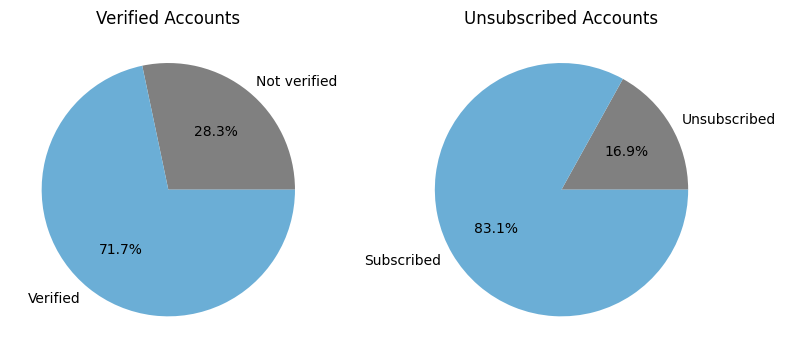

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(8, 6))

ax[0].pie(df['is_verified'].value_counts().sort_values(), labels=['Not verified', 'Verified'], autopct='%1.1f%%', colors=color_palette)
ax[0].set_title('Verified Accounts')

ax[1].pie(df['is_unsubscribed'].value_counts().sort_values(), labels=['Unsubscribed', 'Subscribed'], autopct='%1.1f%%', colors=color_palette)
ax[1].set_title('Unsubscribed Accounts')

plt.tight_layout()
plt.show()

Only 8% of sessions result in an account. The purchase rate is nearly the same for registered and non-registered users.

70% of accounts have verified their emails, and almost 17% of accounts have unsubscribed from the email newsletter.

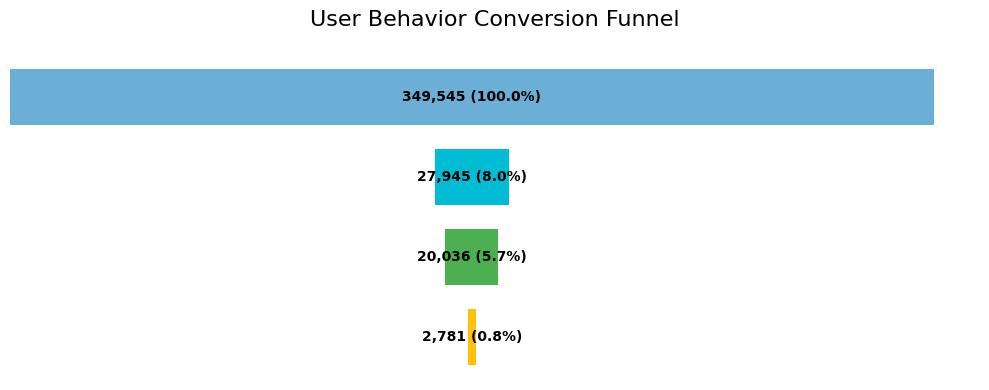

In [ ]:
# Conversion Funnel

total_sessions = df['session_id'].nunique()
total_accounts = df['account_id'].nunique()
total_verified = df[df['is_verified'] == 1]['account_id'].nunique()
total_purchased = df[df['has_purchased'] == 1]['account_id'].nunique()

stages = ['Sessions', 'Accounts', 'Verified', 'Purchased']
values = [total_sessions, total_accounts, total_verified, total_purchased]


def plot_funnel(stages, values):
    fig, ax = plt.subplots(figsize=(10, 4))
    max_val = values[0]
    x_offsets = [(max_val - val) / 2 for val in values]

    colors = ['#6BAED6', '#00BCD4', '#4CAF50', '#FFC107']
    bars = ax.barh(stages, values, left=x_offsets, color=colors, height=0.7)

    ax.invert_yaxis()

    for i, bar in enumerate(bars):
        val = values[i]
        perc = (val / max_val) * 100
        ax.text(max_val/2, i, f'{val:,} ({perc:.1f}%)',
                va='center', ha='center', color='black', fontweight='bold')

    ax.set_title('User Behavior Conversion Funnel', fontsize=16, pad=20)
    ax.axis('off')

    plt.tight_layout()
    plt.show()

plot_funnel(stages, values)

The funnel shows that only 8% of sessions result in accounts, 5.7% verified emails. Purchases were made only by 0.8% of accounts.

####**Sessions & Sales Correlation**

Sessions normality p-value: 0.0087
Sales normality p-value: 0.0211
Spearman's Correlation: 0.8653, p-value: 9.7559e-29


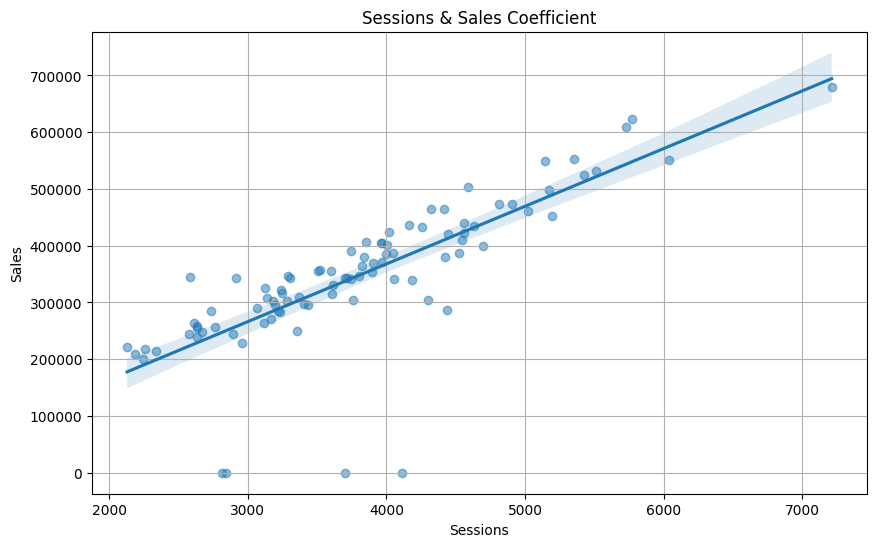

In [ ]:
daily_data = df.groupby('date').agg(
    sessions=('session_id', 'nunique'),
    sales=('product_price', 'sum')
).reset_index()

stat1, p1 = stats.normaltest(daily_data['sessions'])
stat2, p2 = stats.normaltest(daily_data['sales'])
print(f"Sessions normality p-value: {p1:.4f}")
print(f"Sales normality p-value: {p2:.4f}")

# Distributions are not normal, use Spearman
spearman_coef, spearman_p = spearmanr(daily_data['sessions'], daily_data['sales'])
print(f"Spearman's Correlation: {spearman_coef:.4f}, p-value: {spearman_p:.4e}")


plt.figure(figsize=(10, 6))
sns.regplot(data=daily_data, x='sessions', y='sales', scatter_kws={'alpha':0.5})
plt.title('Sessions & Sales Coefficient')
plt.xlabel('Sessions')
plt.ylabel('Sales')
plt.grid(True)
plt.show()


Result: strong positive correlation between daily number of sessions and sales with statistically significant result (Spearman's Correlation Coefficient: 0.8653, p-value: 9.7559e-29)

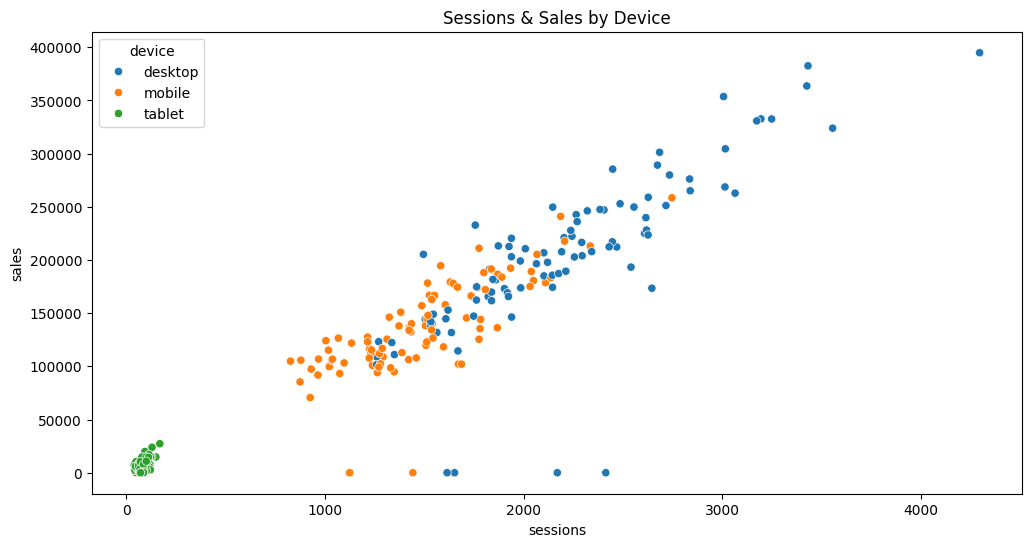

In [ ]:
df_daily_by_device = df.groupby(['date', 'device']).agg(
    sessions=('session_id', 'nunique'),
    sales=('product_price', 'sum')
).reset_index()


plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_daily_by_device, x='sessions', y='sales', hue='device')
plt.title('Sessions & Sales by Device')
plt.show()

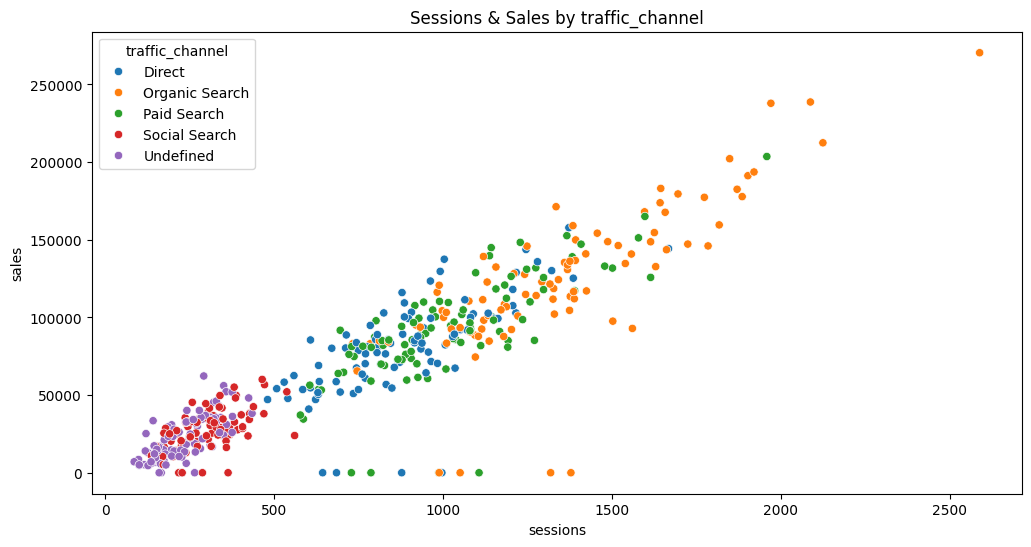

In [ ]:
df_daily_by_channel = df.groupby(['date', 'traffic_channel']).agg(
    sessions=('session_id', 'nunique'),
    sales=('product_price', 'sum')
).reset_index()


plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_daily_by_channel, x='sessions', y='sales', hue='traffic_channel')
plt.title('Sessions & Sales by traffic_channel')
plt.show()

####**Registered Vs Not Registered**

In [ ]:
#Daily Sales

# Normal Distribution Test
with_account = df[df['has_account'] == 1].groupby('date')['product_price'].sum()
without_account = df[df['has_account'] == 0].groupby( 'date')['product_price'].sum()

_, p_value_normaltest_acc = normaltest(with_account)
_, p_value_normaltest_no_acc = normaltest(without_account)


print(f"Normaltest for sample with accounts p-value: {p_value_normaltest_acc}")
print(f"Normaltest for sample without accounts p-value: {p_value_normaltest_no_acc}")


Normaltest for sample with accounts p-value: 0.010929121653065912
Normaltest for sample without accounts p-value: 0.026362411185738954


Distributions are not normal

In [ ]:
u_stat, p_value = mannwhitneyu(with_account, without_account)
print(f"U-statistic: {u_stat}, p-value: {p_value}")

if(p_value < 0.05):
    print("Statistically significant difference between the groups")
else:
    print("No statistically significant difference between the groups")


U-statistic: 352.0, p-value: 3.8805185465235906e-26
Statistically significant difference between the groups


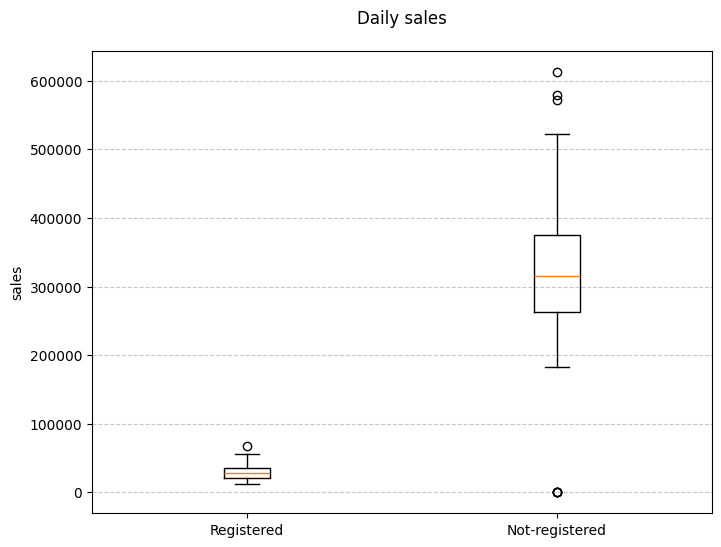

In [ ]:
plt.figure(figsize=(8, 6))
plt.boxplot([with_account, without_account], tick_labels=['Registered', 'Not-registered'])
plt.title('Daily sales', pad=20)
plt.ylabel('sales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Non-registered users generate higher daily sales compared to registered users.

In [ ]:
# Purchases Count Share (Registred Vs Not registred)

has_account = df[df['has_account'] == 1]
no_account = df[df['has_account'] == 0]

registered_purchases = has_account['has_purchased'].sum()
registered_total = len(has_account)

guest_purchases = no_account['has_purchased'].sum()
guest_total = len(no_account)

conv_registered = registered_purchases / registered_total
conv_guest = guest_purchases / guest_total

print(f"Registered conversion: {conv_registered:.2%}")
print(f"Guests Conversion: {conv_guest:.2%}")

z_stat, p_value = sm.stats.proportions_ztest(
    [registered_purchases, guest_purchases],
    [registered_total, guest_total]
)


print(f"\nZ-statistic: {z_stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("There is a statistically significant difference in purchase conversion between registered users and guests.")
else:
    print("No statistically significant difference in purchase conversion between registered users and guests.")


Registered conversion: 9.95%
Guests Conversion: 9.56%

Z-statistic: 2.1121129298863486
P-value: 0.03467676423596537
There is a statistically significant difference in purchase conversion between registered users and guests.


Registered users have slightly higher sales conversion (0.39 percentage points) compared to guests.

####**Subscrbed VS Unsubscribed**


In [ ]:
# pivot statistics

report = df.groupby('is_unsubscribed').agg(
    total_users=('account_id', 'count'),
    total_purchases=('has_purchased', 'sum'),
    median_revenue=('product_price', 'median')
)
report['conversion_rate'] = (report['total_purchases'] / report['total_users']) * 100
print(report)

                 total_users  total_purchases  median_revenue  conversion_rate
is_unsubscribed                                                               
0                      23210             2334           395.0         10.05601
1                       4735              447           450.0         9.440338


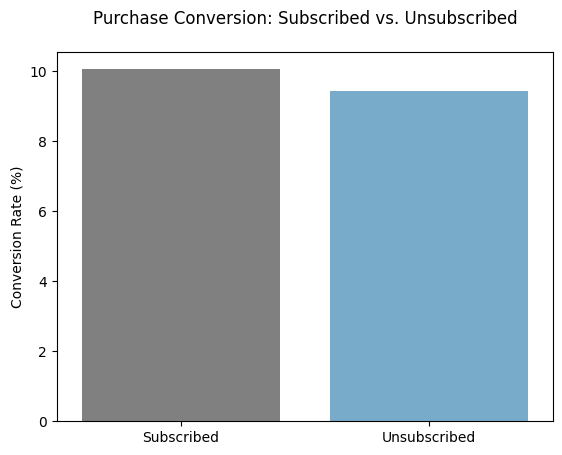

In [ ]:
analysis = df.groupby('is_unsubscribed')['has_purchased'].mean() * 100

sns.barplot(x=analysis.index, y=analysis.values, palette=color_palette,  hue=analysis.index, legend=None)

plt.xticks(ticks=[0, 1], labels=['Subscribed', 'Unsubscribed'])
plt.ylabel('Conversion Rate (%)')
plt.xlabel(None)
plt.title('Purchase Conversion: Subscribed vs. Unsubscribed', pad=20)
plt.show()

In [ ]:
# Purchases Conversion (Subscribed Vs Unsubscribed)

subscribed = df[df['is_unsubscribed'] == 0]
unsubscribed = df[df['is_unsubscribed'] == 1]

subscribed_purchases = subscribed['has_purchased'].sum()
subscribed_total = len(subscribed)

unsubscribed_purchases = unsubscribed['has_purchased'].sum()
unsubscribed_total = len(unsubscribed)

conv_sub = subscribed_purchases / subscribed_total
conv_unsub = unsubscribed_purchases / unsubscribed_total

print(f"Subscribed conversion: {conv_sub:.2%}")
print(f"Unsubscribed conversion: {conv_unsub:.2%}")

z_stat, p_value = sm.stats.proportions_ztest(
    [subscribed_purchases, unsubscribed_purchases],
    [subscribed_total, unsubscribed_total]
)

print(f"\nZ-statistic: {z_stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("There is a statistically significant difference in purchase conversion between subscribed and unsubscribed users.")
else:
    print("No statistically significant difference in purchase conversion between subscribed and unsubscribed users.")

Subscribed conversion: 10.06%
Unsubscribed conversion: 9.44%

Z-statistic: 1.2897602654930744
P-value: 0.19713390786902185
No statistically significant difference in purchase conversion between subscribed and unsubscribed users.


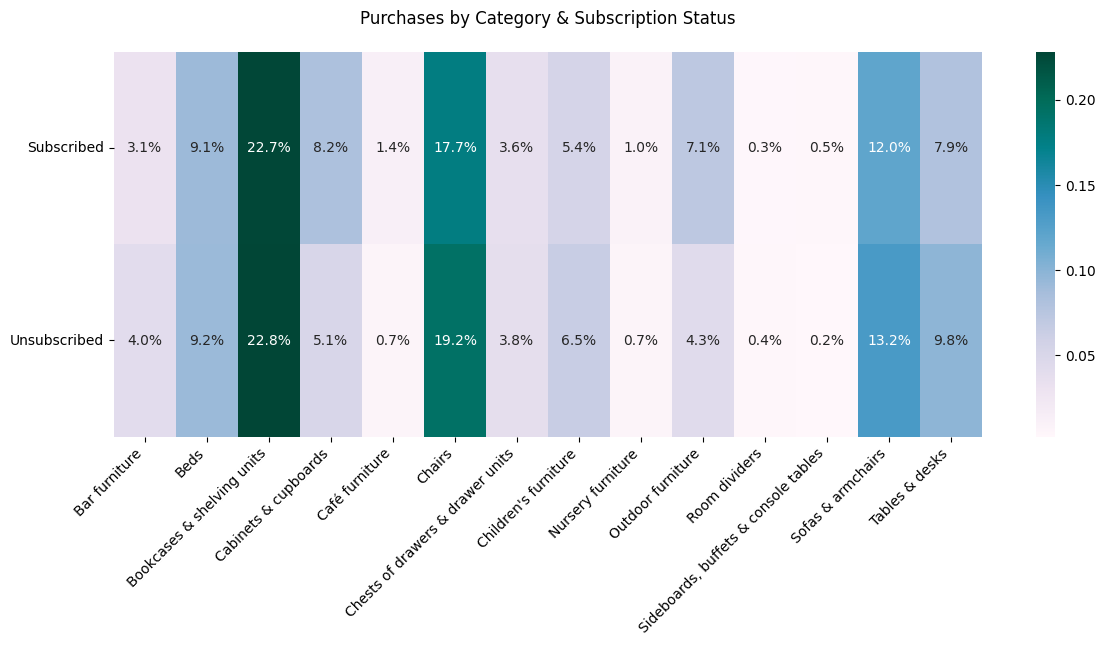

In [ ]:
pivot = df.groupby(['is_unsubscribed', 'product_category'])['has_purchased'].sum().unstack()
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

aliases = {0: 'Subscribed', 1: 'Unsubscribed'}
pivot_norm.rename(index=aliases, inplace=True)


plt.figure(figsize=(14, 5))
sns.heatmap(pivot_norm,
            annot=True,
            fmt='.1%',
            cmap='PuBuGn')

plt.ylabel(None)
plt.xlabel(None)
plt.title('Purchases by Category & Subscription Status', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0, ha='right')
plt.show()

In [ ]:
# Normal Distribution Test
sub = df[df['is_unsubscribed'] == 1]['product_price'].dropna()
unsub = df[df['is_unsubscribed'] == 0]['product_price'].dropna()

_, p_value_normaltest_sub = normaltest(sub)
_, p_value_normaltest_unsub = normaltest(unsub)


print(f"Normaltest for subscribed sample p-value: {p_value_normaltest_sub}")
print(f"Normaltest for unsubscribed sample p-value: {p_value_normaltest_unsub}")

Normaltest for subscribed sample p-value: 5.809081148138178e-59
Normaltest for unsubscribed sample p-value: 7.781273632548209e-299


Distributions are not normal

In [ ]:
# Revenue (Subscribed Vs Unsubscribed)

res_sub = df[df['is_unsubscribed'] == 0]['product_price'].dropna()
res_unsub = df[df['is_unsubscribed'] == 1]['product_price'].dropna()

median_sub = res_sub.median()
median_unsub = res_unsub.median()

print(f"Median revenue Subscribed: {median_sub}")
print(f"Median revenue Unsubscribed: {median_unsub}\n")

u_stat, p_val = mannwhitneyu(res_sub, res_unsub)

print(f"P-value: {p_val}")

if p_val < 0.05:
    print("There is a statistically significant difference in revenue between subscribed and unsubscribed users.")
else:
    print("No statistically significant difference in revenue between subscribed and unsubscribed users.")


Median revenue Subscribed: 395.0
Median revenue Unsubscribed: 450.0

P-value: 0.16780192609435507
No statistically significant difference in revenue between subscribed and unsubscribed users.


####**Devices**

In [ ]:
 #  Function does the Chi-square test for different dimensions

def chi_test(metric_1, metric_2):
  contingency = pd.crosstab(df[metric_1], df[metric_2])

  print("Contingency table:")
  print(contingency)


  chi2, p, dof, expected = chi2_contingency(contingency)

  print(f"\nChi2 statistic: {chi2}")
  print(f"P-value: {p}")

  if p < 0.05:
      print(f"There is a statistically significant association between {metric_1} and {metric_2}.")
  else:
      print(f"No statistically significant association between {metric_1} and {metric_2}.")

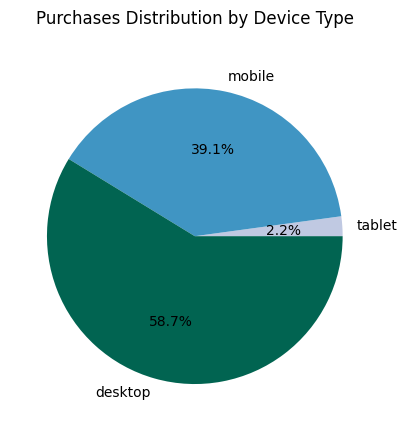

In [ ]:
cmap = plt.get_cmap('PuBuGn')
color_palette = cmap(np.linspace(0.3, 0.9, 3))

df.groupby('device')['has_purchased']\
  .sum().sort_values()\
  .plot(kind='pie', autopct='%1.1f%%', colors=color_palette)


plt.title('Purchases Distribution by Device Type', pad=20)
plt.ylabel(None)
plt.show()

P-value for devices: 8.868144988076332e-48
There is a statistically significant difference between the groups


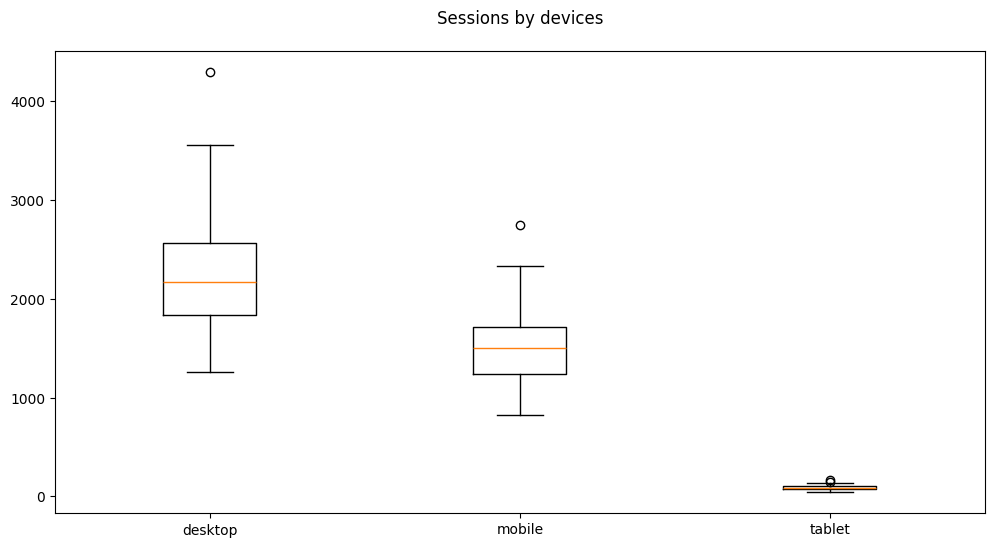

In [ ]:
# Daily Sessions by devices

channel_data = [df[df['device'] == c].groupby('date')['session_id'].nunique() for c in df['device'].unique()]

stat, p_value = kruskal(*channel_data)
print(f"P-value for devices: {p_value}")

if(p_value < 0.05):
    print("There is a statistically significant difference between the groups")
else:
    print("No statistically significant difference between the groups")

plt.figure(figsize=(12, 6))
plt.boxplot(channel_data, tick_labels=df['device'].unique())
plt.title('Sessions by devices', pad = 20)
plt.show()

In [ ]:
# unsub rate by device
device_unsub = pd.pivot_table(df, values='is_unsubscribed', index='device', aggfunc='mean')
device_unsub = device_unsub * 100

print(f"Unsubscribe rate through devices:\n")

print(device_unsub.sort_values(by='is_unsubscribed', ascending=False))

Unsubscribe rate through devices:

         is_unsubscribed
device                  
mobile          17.06196
desktop         16.90321
tablet              16.0


In [ ]:
# unsubscribed users share by device
chi_test('device', 'is_unsubscribed')

Contingency table:
is_unsubscribed      0     1
device                      
desktop          13642  2775
mobile            9022  1856
tablet             546   104

Chi2 statistic: 0.5385598759685315
P-value: 0.7639293728638771
No statistically significant association between device and is_unsubscribed.


In [ ]:
# verified users share by device

chi_test('device', 'is_verified')

Contingency table:
is_verified     0      1
device                  
desktop      4682  11735
mobile       3024   7854
tablet        203    447

Chi2 statistic: 4.484457421817898
P-value: 0.10622150335068298
No statistically significant association between device and is_verified.


In [ ]:
# Purchases share by device

chi_test('device', 'has_purchased')

Contingency table:
has_purchased       0      1
device                      
desktop        184727  19702
mobile         124154  13113
tablet           7126    723

Chi2 statistic: 2.0392209727299457
P-value: 0.36073542417743887
No statistically significant association between device and has_purchased.


There is statistically significant difference between *device* and *session count*, but no statistically significant association between *device type* and *unsubscribtion*, *verification* and *purchases*.

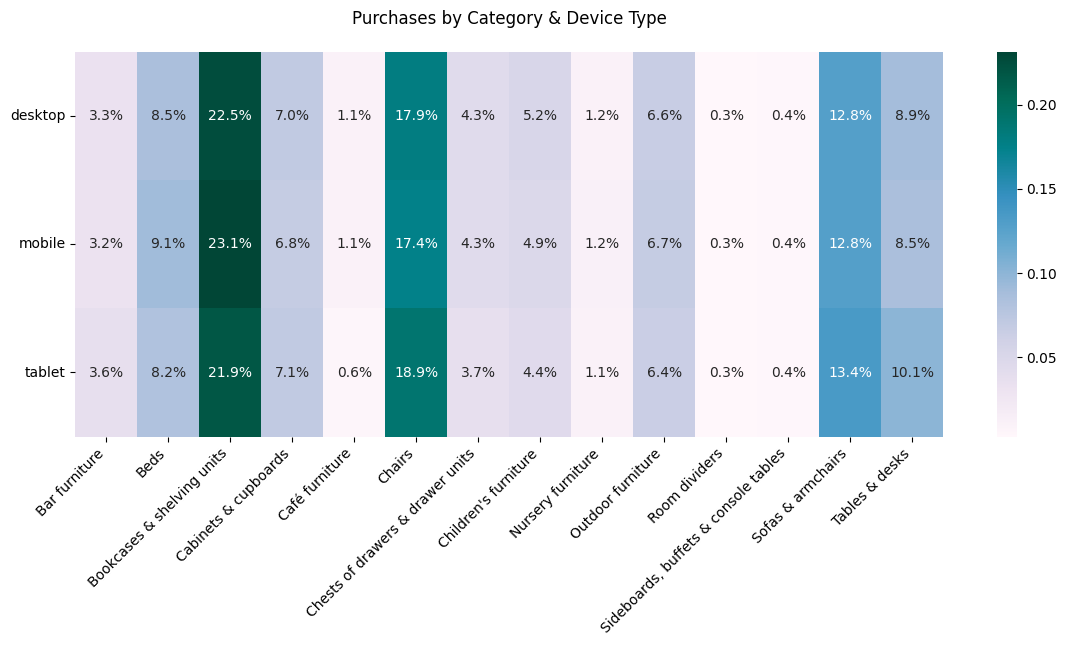

In [ ]:
pivot = df.groupby(['device', 'product_category'])['has_purchased'].sum().unstack()
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

plt.figure(figsize=(14, 5))
sns.heatmap(pivot_norm,
            annot=True,
            fmt='.1%',
            cmap='PuBuGn')

plt.ylabel(None)
plt.xlabel(None)
plt.title('Purchases by Category & Device Type', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0, ha='right')
plt.show()

####**Traffic Channels**

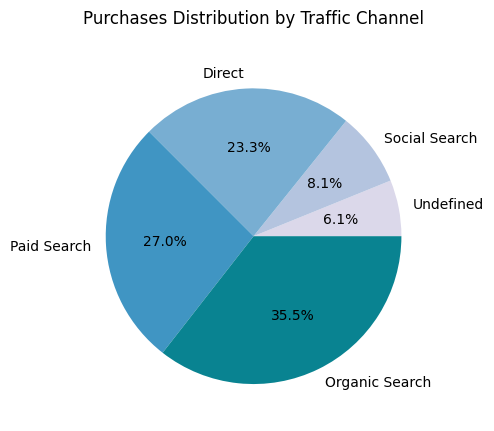

In [ ]:
cmap = plt.get_cmap('PuBuGn')
color_palette = cmap(np.linspace(0.2, 1, 7))

df.groupby('traffic_channel')['has_purchased']\
  .sum()\
  .sort_values(ascending=True)\
  .plot(kind='pie', autopct='%1.1f%%', colors=color_palette)

plt.title('Purchases Distribution by Traffic Channel', pad=20)
plt.ylabel(None)
plt.show()


P-value for channels: 1.3970361025991997e-78
There is a statistically significant difference between the groups


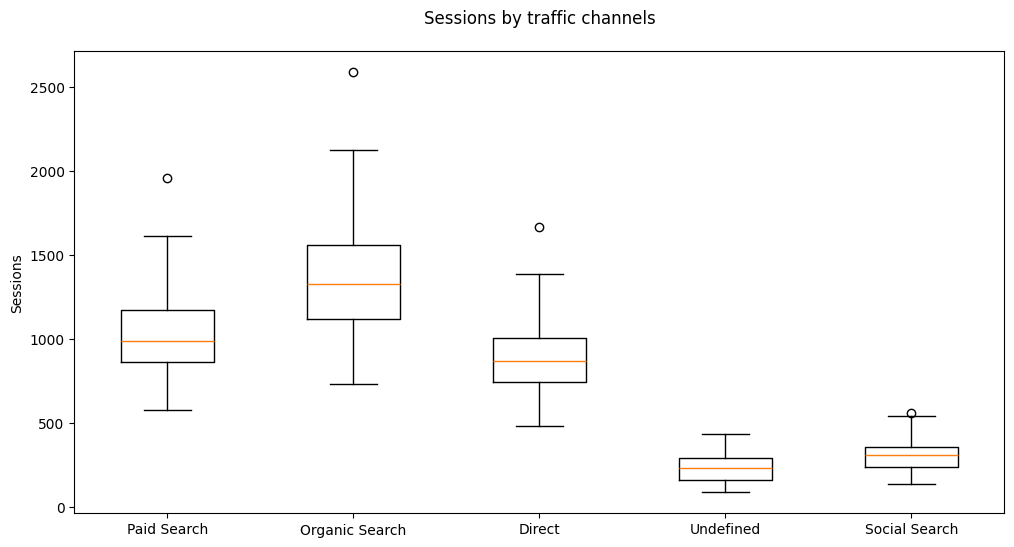

In [ ]:
# Sessions by traffic channels

channel_data = [df[df['traffic_channel'] == c].groupby('date')['session_id'].nunique() for c in df['traffic_channel'].unique()]

stat, p_value = kruskal(*channel_data)
print(f"P-value for channels: {p_value}")

if(p_value < 0.05):
    print("There is a statistically significant difference between the groups")
else:
    print("No statistically significant difference between the groups")

plt.figure(figsize=(12, 6))
plt.boxplot(channel_data, tick_labels=df['traffic_channel'].unique())
plt.title('Sessions by traffic channels', pad=20)
plt.ylabel('Sessions')
plt.show()

In [ ]:
# verified users share by traffic channel

chi_test('traffic_channel', 'is_verified')

Contingency table:
is_verified         0     1
traffic_channel            
Direct           1782  4732
Organic Search   2839  7196
Paid Search      2117  5350
Social Search     679  1533
Undefined         492  1225

Chi2 statistic: 9.233389256478267
P-value: 0.05552336911044174
No statistically significant association between traffic_channel and is_verified.


In [ ]:
# unsub rate by traffic_channel
device_unsub = pd.pivot_table(df, values='is_unsubscribed', index='traffic_channel', aggfunc='mean')
device_unsub = device_unsub * 100

print(f"Unsubscribe rate through traffic channels:\n")

print(device_unsub.sort_values(by='is_unsubscribed', ascending=False))


Unsubscribe rate through traffic channels:

                 is_unsubscribed
traffic_channel                 
Organic Search         17.339312
Direct                 17.009518
Undefined              16.773442
Paid Search            16.606401
Social Search          16.229656


In [ ]:
# unsubscribed users share by traffic channel

chi_test('traffic_channel', 'is_unsubscribed')

Contingency table:
is_unsubscribed     0     1
traffic_channel            
Direct           5406  1108
Organic Search   8295  1740
Paid Search      6227  1240
Social Search    1853   359
Undefined        1429   288

Chi2 statistic: 2.5764834325679518
P-value: 0.6309945818303565
No statistically significant association between traffic_channel and is_unsubscribed.


In [ ]:
# Purchases share by traffic channel

chi_test('traffic_channel', 'has_purchased')

Contingency table:
has_purchased         0      1
traffic_channel               
Direct            73582   7800
Organic Search   112504  11921
Paid Search       85299   9042
Social Search     25198   2716
Undefined         19424   2059

Chi2 statistic: 0.6396719443461314
P-value: 0.9585548370612956
No statistically significant association between traffic_channel and has_purchased.


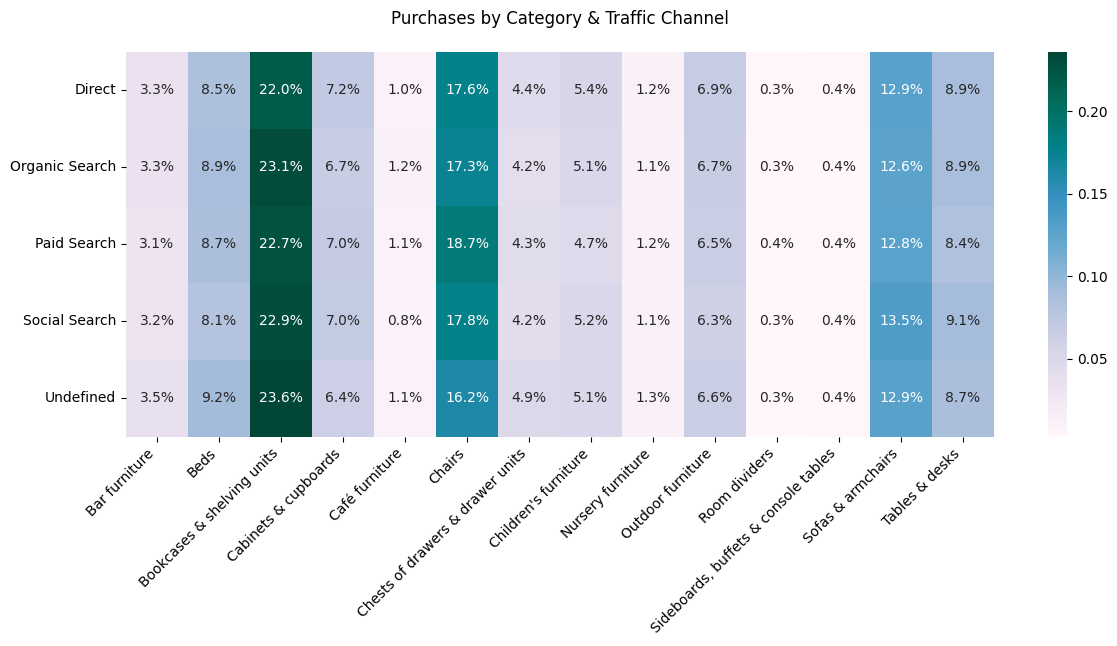

In [ ]:
pivot = df.groupby(['traffic_channel', 'product_category'])['has_purchased'].sum().unstack()
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

plt.figure(figsize=(14, 5))
sns.heatmap(pivot_norm,
            annot=True,
            fmt='.1%',
            cmap='PuBuGn')

plt.ylabel(None)
plt.xlabel(None)
plt.title('Purchases by Category & Traffic Channel', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0, ha='right')
plt.show()

There is statistically significant difference between *traffic channel* and *session count*, but no statistically significant association between *traffic channel* and *unsubscribtion*, *verification* and *purchases*.

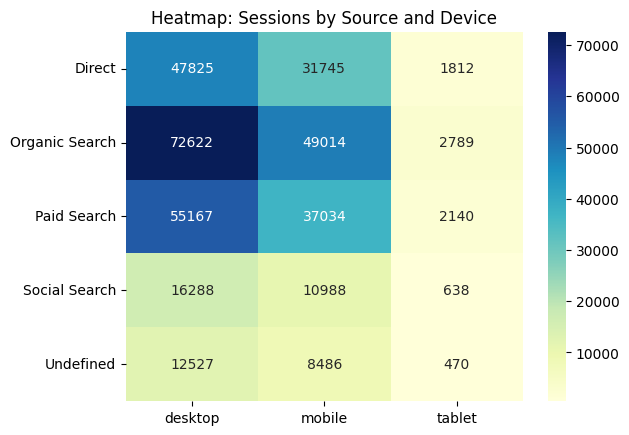

In [ ]:
pivot_report = df.pivot_table(
    index='traffic_channel',
    columns='device',
    values='session_id',
    aggfunc='count',
    fill_value=0
)

sns.heatmap(pivot_report.astype(float), annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Heatmap: Sessions by Source and Device')
plt.xlabel(None)
plt.ylabel(None)
plt.show()

Most sessions come from desktop devices and organic search. Mobile traffic shows a similar distribution across traffic sources, but with lower volumes. Tablet has the smallest number of sessions.

####**Dynamics**

In [ ]:

# Color palette
all_categories = pd.concat([df['traffic_channel'], df['device']]).unique()
color_sequence = px.colors.qualitative.Safe
color_map = {cat: color_sequence[i % len(color_sequence)] for i, cat in enumerate(all_categories)}


# Charts
dimensions = ['total', 'traffic_channel', 'device']

fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.1,
    subplot_titles=("Accounts Dynamics", "Verifications Dynamics")
)

buttons = []
total_traces = 0

for i, dim in enumerate(dimensions):
    if dim == 'total':
        agg = df.groupby('date').agg(
            accounts=('account_id', 'nunique'),
            verifications=('is_verified', 'sum')
        ).sort_index()
    else:
        agg = df.groupby(['date', dim]).agg(
            accounts=('account_id', 'nunique'),
            verifications=('is_verified', 'sum')
        ).unstack(fill_value=0)

    visible = (i == 0)
    current_dim_traces = 0

    if dim == 'total':
        fig.add_trace(go.Scatter(
            x=agg.index.astype(str), y=agg['accounts'],
            name='Total Accounts', line=dict(color='royalblue', width=3),
            visible=visible
        ), row=1, col=1)

        fig.add_trace(go.Scatter(
            x=agg.index.astype(str), y=agg['verifications'],
            name='Total Verifications', line=dict(color='darkorange', width=3),
            visible=visible
        ), row=2, col=1)
        current_dim_traces = 2
    else:
        for col in agg['accounts'].columns:
            color = color_map.get(col)

            fig.add_trace(go.Scatter(
                x=agg.index.astype(str), y=agg['accounts'][col],
                name=col,
                line=dict(color=color),
                legendgroup=col,
                visible=visible
            ), row=1, col=1)


            fig.add_trace(go.Scatter(
                x=agg.index.astype(str), y=agg['verifications'][col],
                name=col,
                line=dict(color=color),
                legendgroup=col,
                showlegend=False,
                visible=visible
            ), row=2, col=1)
            current_dim_traces += 2

    buttons.append(dict(
        label=dim.replace('_', ' ').title(),
        method="update",
        args=[{"visible": []},
              {"title": f"Dynamics for: {dim.replace('_', ' ').title()}"}]
    ))

    total_traces += current_dim_traces


trace_idx = 0
for i, dim in enumerate(dimensions):
    if dim == 'total':
        dim_trace_count = 2
    else:
        dim_trace_count = len(df[dim].unique()) * 2

    v_mask = [False] * total_traces
    v_mask[trace_idx : trace_idx + dim_trace_count] = [True] * dim_trace_count
    buttons[i]["args"][0]["visible"] = v_mask

    trace_idx += dim_trace_count


fig.update_layout(
    updatemenus=[dict(
        buttons=buttons,
        direction="down",
        showactive=True,
        x=0.5, xanchor="center", y=1.25
    )],
    height=800,
    template="plotly_white",
    hovermode="x unified",
    legend=dict(traceorder="normal")
)

fig.update_yaxes(title_text="Count of Accounts", row=1, col=1)
fig.update_yaxes(title_text="Count of Verifications", row=2, col=1)
fig.update_xaxes(title_text="Date", row=2, col=1)

fig.show()

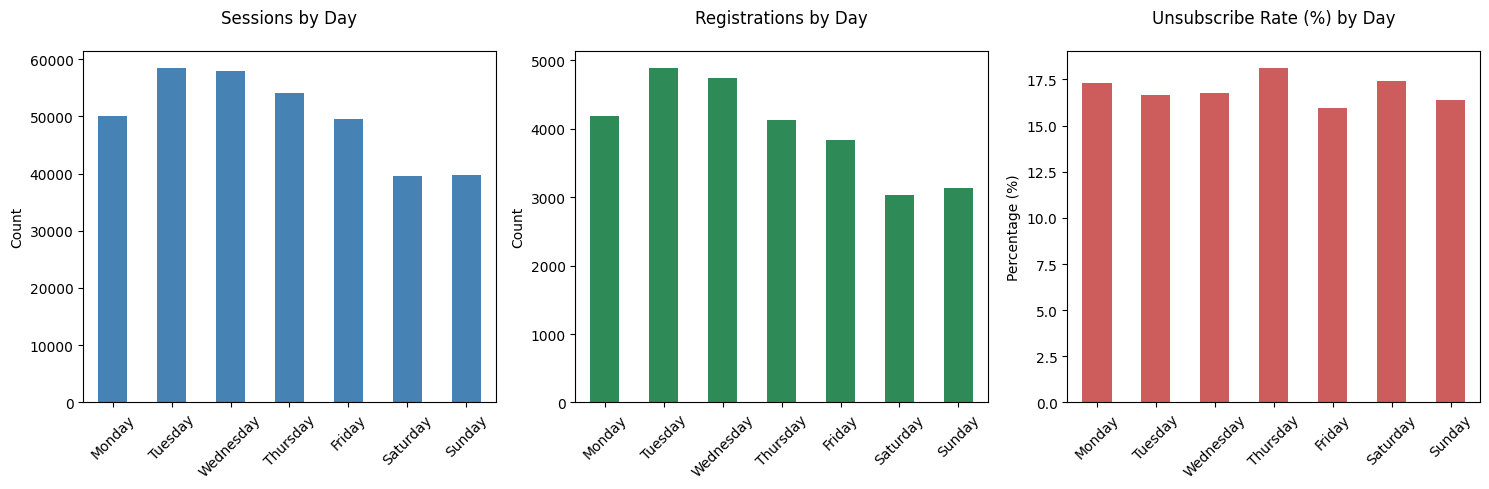

In [ ]:
# Weekly patterns

day_name = df['date'].dt.day_name()
weekly_sessions = df.groupby(day_name)['session_id'].nunique()
weekly_accounts = df.groupby(day_name)['account_id'].nunique()
weekly_unsub_rate = (df.groupby(day_name)['is_unsubscribed'].mean() * 100)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_sessions = weekly_sessions.reindex(day_order)
weekly_accounts = weekly_accounts.reindex(day_order)
weekly_unsub_rate = weekly_unsub_rate.reindex(day_order)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

weekly_sessions.plot(kind='bar', ax=ax[0], color='steelblue')
ax[0].set_title('Sessions by Day', pad=20)
ax[0].set_ylabel('Count')

weekly_accounts.plot(kind='bar', ax=ax[1], color='seagreen')
ax[1].set_title('Registrations by Day', pad=20)
ax[1].set_ylabel('Count')

weekly_unsub_rate.plot(kind='bar', ax=ax[2], color='indianred')
ax[2].set_title('Unsubscribe Rate (%) by Day', pad=20)
ax[2].set_ylabel('Percentage (%)')

for a in ax:
    a.set_xlabel(None)
    a.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

There are clear weekly patterns, with peaks on Tuesday and Wednesday for both sessions and registrations. The unsubscribe rate is almost flat throughout the week.

####**Geography**

In [ ]:
#top-7 countries

df_top_countries = df['country'].value_counts().head(7)
df_top_countries = df[df['country'].isin(df_top_countries.index)]

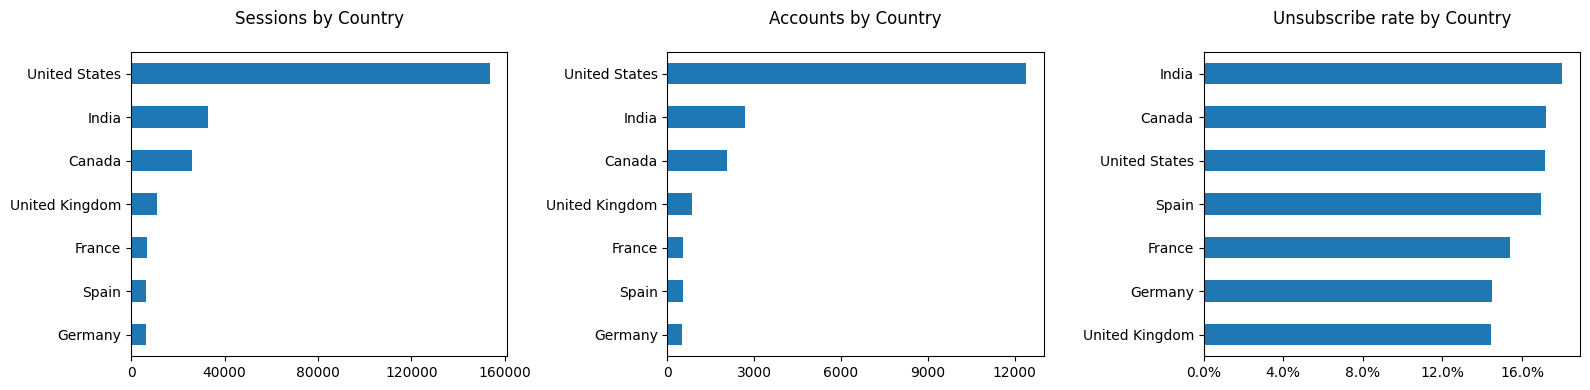

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

for a in ax:
    a.xaxis.set_major_locator(mtick.MaxNLocator(5))


df_top_countries.groupby('country')['session_id'].nunique().sort_values().plot(kind='barh', ax=ax[0])
ax[0].set_title('Sessions by Country', pad=20)
ax[0].set_xlabel(None)
ax[0].set_ylabel(None)

df_top_countries.groupby('country')['account_id'].nunique().sort_values().plot(kind='barh', ax=ax[1])
ax[1].set_title('Accounts by Country', pad=20)
ax[1].set_xlabel(None)
ax[1].set_ylabel(None)


df_top_countries.groupby('country')['is_unsubscribed'].mean().sort_values().plot(kind='barh', ax=ax[2])
ax[2].set_title('Unsubscribe rate by Country', pad=20)
ax[2].set_xlabel(None)
ax[2].set_ylabel(None)
ax[2].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))


plt.tight_layout()
plt.show()

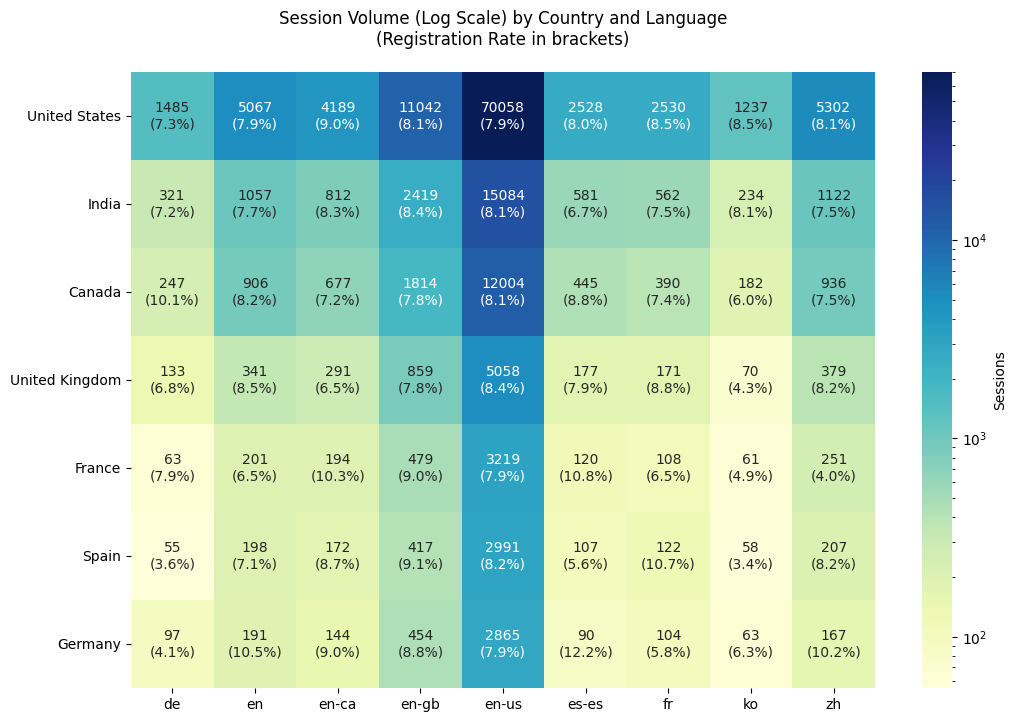

In [ ]:
pivot_stats = df_top_countries.pivot_table(
    index='country',
    columns='browser_language',
    values='has_account',
    aggfunc=['mean', 'count'],
    fill_value=0
).drop(columns=['undefined'], level=1, errors='ignore')

rate_data = pivot_stats['mean'] * 100
count_data = pivot_stats['count']

country_order = count_data.sum(axis=1).sort_values(ascending=False).index

count_data = count_data.reindex(country_order)
rate_data = rate_data.reindex(country_order)


labels = count_data.copy().astype(str)
for i in range(count_data.shape[0]):
    for j in range(count_data.shape[1]):
        c = count_data.iloc[i, j]
        r = rate_data.iloc[i, j]
        labels.iloc[i, j] = f"{int(c)}\n({r:.1f}%)"


plt.figure(figsize=(12, 8))
sns.heatmap(
    count_data,
    annot=labels,
    fmt="",
    cmap='YlGnBu',
    cbar_kws={'label': 'Sessions'},
    norm=colors.LogNorm()
)

plt.title('Session Volume (Log Scale) by Country and Language\n(Registration Rate in brackets)', pad=20)
plt.xlabel(None)
plt.ylabel(None)
plt.yticks(rotation=0, ha='right')
plt.show()

The country with the highest session count is the United States, and the most common language is English (especially en-us). Registration rates are approximately the same across all countries and languages (around 10%). The lowest registration rate is observed for Korean, for almost all countries except the USA and India (4-6%).

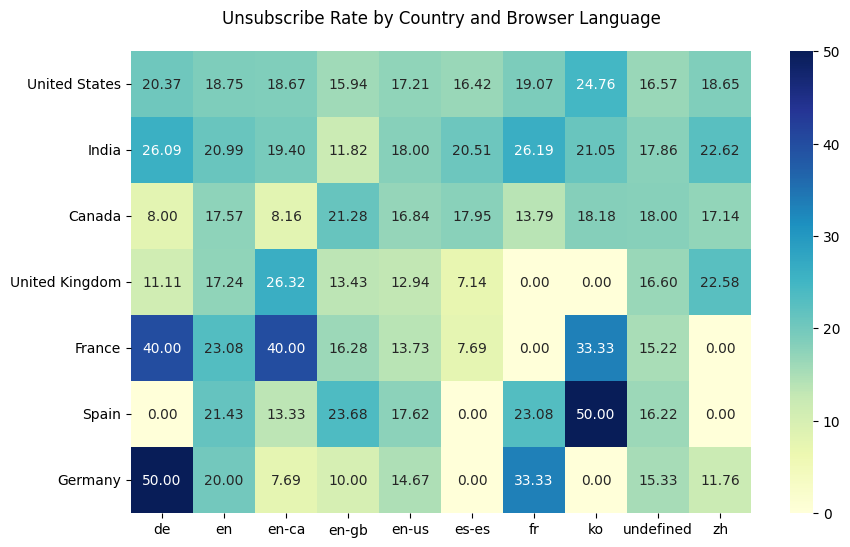

In [ ]:
pivot_report = df_top_countries.pivot_table(
    index='country',
    columns='browser_language',
    values='is_unsubscribed',
    aggfunc='mean',
    fill_value=0
)

pivot_report = pivot_report * 100
country_order = count_data.sum(axis=1).sort_values(ascending=False).index

pivot_report = pivot_report.reindex(country_order)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_report.astype(float), annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Unsubscribe Rate by Country and Browser Language', pad=20)
plt.xlabel(None)
plt.ylabel(None)
plt.show()

High unsubscribe rates are observed in countries and languages with a small number of sessions. The likely reason may be incorrect email language or other related issues, such as mismatched content, or irrelevant offers.

In [ ]:
# Unsubscribe rate throughout continents

continent_counts = df.groupby('continent')['is_unsubscribed'].count()
print(continent_counts)

continent
(not set)       53
Africa         266
Americas     15520
Asia          6664
Europe        5170
Oceania        272
Name: is_unsubscribed, dtype: Int64


In [ ]:
continent_unsub = (
    df.groupby('continent')['is_unsubscribed']
    .mean() * 100
)
print(f"Unsubscribe rate through continents:\n")

print(continent_unsub.sort_values(ascending=False))


Unsubscribe rate through continents:

continent
Oceania          18.75
Asia         17.331933
Americas     17.048969
Europe       16.286267
Africa       13.909774
(not set)      7.54717
Name: is_unsubscribed, dtype: Float64


In [ ]:
contingency = pd.crosstab(df['continent'], df['is_unsubscribed'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-square: {chi2:.4f}, p-value: {p:.4f}")

Chi-square: 8.1195, p-value: 0.1498


There is no statistically significant difference in unsubscribe rate throughout continents.

In [ ]:
# Statistical difference between shares of Europe and Americas for organic Traffic

europe_df = df[df['continent'] == 'Europe']
us_df = df[df['continent'] == 'Americas']

europe_share = europe_df[europe_df['traffic_channel'] == 'Organic Search']['session_id'].nunique()
us_share = us_df[us_df['traffic_channel'] == 'Organic Search']['session_id'].nunique()

z_stat, p_value = sm.stats.proportions_ztest([europe_share, us_share], [europe_df['session_id'].nunique(), us_df['session_id'].nunique()])

print(f"Z-statistic: {z_stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("There is a statistically significant difference between Europe and Americas.")
else:
    print("No statistically significant difference between Europe and Americas.")


Z-statistic: 0.28951412926103953
P-value: 0.7721879690501752
No statistically significant difference between Europe and Americas.


## Code to save to csv

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# # Then save to a folder in your Drive
# df.to_csv('/content/drive/MyDrive/Mate_tasks/customers.csv', index=False)

#**Conclusions & Recommendations**

**1. Funnel**

The funnel shows that only 8% of all sessions result in account creation, and 5.7% result in email verification. 9.5% of all sessions made a purchase. The share of registered users with purchases is equal to 0.8%.

**2. Sessions vs. Sales**

There is a strong positive correlation between the daily number of sessions and daily sales. The result is statistically significant (Spearman's Correlation Coefficient: 0.8653, p-value: 9.7559e-29). This pattern is consistent across devices and traffic channels.

**3. Has Account vs. Sales (Total Daily Revenue)**

Non-registered users generate higher daily revenue (Mann-Whitney test, p = 3.88e-26). However, this result reflects differences in aggregated daily revenue and does not isolate the effect of session volume or average order value.

There is also a statistically significant difference in conversion rate (purchases) between registered and non-registered users (z-test, p = 0.034): registered users have a conversion rate that is 0.39 percentage points higher.

**4. Subscribed vs. Unsubscribed**

83% of accounts are subscribed.

There is no statistically significant difference in purchase conversion between subscribed and unsubscribed users (z-test, p = 0.197).

Subscribed and unsubscribed users purchase similar product categories. The main differences are: Cabinets & cupboards: 8.2% (subscribed) vs. 5.1% (unsubscribed), Outdoor furniture: 7.1% (subscribed) vs. 4.3% (unsubscribed)

Unsubscribed users buy slightly more Sofas & armchairs (13.2% vs. 12%) and Tables & desks (9.8% vs. 7.9%).

There is no statistically significant difference in revenue between subscribed and unsubscribed users (Mann-Whitney test, p = 0.1678).

**5. Devices**

58.7% of sessions are from desktop, 39.1% from mobile, and 2.2% from tablet.

There is a statistically significant relationship between device and session count (Kruskal, p = 8.86e-48), but no statistically significant association between device and unsubscription, verification, or purchases (chi-square tests).

There is almost no difference in the distribution of purchased categories across devices.

**6. Traffic Channels**

Traffic distribution: 35% organic, 27% paid, 23.3% direct, 8.1% social search, and 6.1% undefined.

There is a statistically significant difference between traffic channel and session count (Kruskal test, p = 1.39e-78). However, there is no statistically significant association between traffic channel and unsubscription, verification, or purchases (chi-square tests).

There is almost no difference in purchased category distribution across traffic channels.

**7. Dynamics**

There is clear weekly seasonality in sessions and registrations, with peaks on Tuesday and Wednesday and lower values on Saturday and Sunday. Paid campaigns may perform better when launched at the beginning of the week due to higher session volume.

The unsubscribe rate is relatively stable throughout the week, with a slight peak on Thursday. However, the difference is minor and may not be actionable.

**8. Geography**

Top 3 countries: USA, India, and Canada.

The USA has significantly more sessions and accounts compared to other countries.

The unsubscribe rate is similar across all continents. The difference is not statistically significant (chi-square test, p = 0.15), and the observed variation — including the higher rate in Oceania — is likely due to chance, particularly given the small sample size in that region.

There is no statistically significant difference between Europe and the Americas in organic traffic share (z-test, p = 0.77).